In [2]:
# Imports
import sys
import json
from pathlib import Path
sys.path.insert(0, "..") 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from catboost import CatBoostClassifier

from src.constants import (
    TARGET_COL,
    MULTILABEL_COLS,
    CATEGORICAL_COLS,
    CLASS_LABELS,
    RANDOM_STATE,
    CV_SPLITS,
    PROCESSED_DATA_PATH,
    ARTEFACTS_PATH
)

from src.preprocessing import load_processed_dataset, temporal_train_val_test_split

from src.encoders import (
    fit_mlb_encoder,
    fit_ohe_encoder,
    build_mlb_cat_matrix,
    build_mlb_ohe_matrix,
    save_encoders
)

from src.evaluation import (
    evaluate_classification_model,
    fit_catboost_classifier,
    compare_results_table
)

from src.visualisations import (
    plot_calibration_curve,
    plot_feature_importance,
    get_original_feature
)

In [3]:
# Load preprocessed dataset
df = load_processed_dataset(PROCESSED_DATA_PATH)
display(df.info())

# Apply and verify the temporal train/test split
df_train, df_val, df_test = temporal_train_val_test_split(df)
print(f"\nTraining rows: {len(df_train)}")
print(f"Validation rows: {len(df_val)}")
print(f"Testing rows: {len(df_test)}")
print(f"\nTraining timeframe:\n {df_train[["year", "quarter"]].drop_duplicates().sort_values(['year', 'quarter']).to_string(index=False)}")
print(f"\nValidation timeframe:\n {df_val[["year", "quarter"]].drop_duplicates().sort_values(['year', 'quarter']).to_string(index=False)}")
print(f"\nTesting timeframe:\n {df_test[["year", "quarter"]].drop_duplicates().sort_values(['year', 'quarter']).to_string(index=False)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9250 entries, 0 to 9249
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   year                       9250 non-null   int64 
 1   quarter                    9250 non-null   object
 2   data_subject_type          9250 non-null   object
 3   data_type                  9250 non-null   object
 4   decision_taken             9250 non-null   object
 5   incident_category          9250 non-null   object
 6   incident_type              9250 non-null   object
 7   no_data_subjects_affected  9250 non-null   object
 8   time_taken_to_report       9250 non-null   object
dtypes: int64(1), object(8)
memory usage: 650.5+ KB


None


Training rows: 6165
Validation rows: 1147
Testing rows: 1938

Training timeframe:
  year quarter
 2021   Qtr 2
 2021   Qtr 3
 2021   Qtr 4
 2022   Qtr 1
 2022   Qtr 2
 2022   Qtr 3
 2022   Qtr 4
 2023   Qtr 1
 2023   Qtr 2
 2023   Qtr 3
 2023   Qtr 4
 2024   Qtr 1
 2024   Qtr 2

Validation timeframe:
  year quarter
 2024   Qtr 3
 2024   Qtr 4

Testing timeframe:
  year quarter
 2025   Qtr 1
 2025   Qtr 2
 2025   Qtr 3
 2025   Qtr 4


In [4]:
print(df_train[TARGET_COL].value_counts(normalize=True))
print(df_val[TARGET_COL].value_counts(normalize=True))
print(df_test[TARGET_COL].value_counts(normalize=True))

decision_taken
Informal Action Taken    0.797405
No Further Action        0.117599
Investigation Pursued    0.084996
Name: proportion, dtype: float64
decision_taken
Informal Action Taken    0.800349
No Further Action        0.161290
Investigation Pursued    0.038361
Name: proportion, dtype: float64
decision_taken
Informal Action Taken    0.947368
No Further Action        0.037152
Investigation Pursued    0.015480
Name: proportion, dtype: float64


In [5]:
# Fit encoders on the training set 
mlb_encoder = fit_mlb_encoder(df_train, MULTILABEL_COLS)
ohe_encoder = fit_ohe_encoder(df_train, CATEGORICAL_COLS)

# Verify the number of unique labels found for each multilabel column
for col, encoder in mlb_encoder.items():
    print(f"{col}: {len(encoder.classes_)} unique labels found")

data_subject_type: 9 unique labels found
data_type: 16 unique labels found


In [6]:
# Build mlb + categorical feature matrices for CatBoost native handling
X_train_cat, cat_feature_indices = build_mlb_cat_matrix(df_train, mlb_encoder)
X_val_cat, _ = build_mlb_cat_matrix(df_val, mlb_encoder)
X_test_cat, _ = build_mlb_cat_matrix(df_test, mlb_encoder)

y_train = df_train[TARGET_COL].reset_index(drop=True)
y_val = df_val[TARGET_COL].reset_index(drop=True)
y_test = df_test[TARGET_COL].reset_index(drop=True)

X_train_val_cat = pd.concat([X_train_cat, X_val_cat], axis=0).reset_index(drop=True)
y_train_val = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

print(f"Categorical indicies: {cat_feature_indices}")
print(f"Categorical columns: {CATEGORICAL_COLS}")
print(f"X_train_cat shape: {X_train_cat.shape}")
print(f"X_val_cat shape: {X_val_cat.shape}")
print(f"X_test_cat shape: {X_test_cat.shape}")
print(f"\nHead of X_train_cat:\n {X_train_cat.head(3).to_string()}")

assert X_train_cat.isnull().sum().sum() == 0, "Null values found in X_train_cat"
assert X_test_cat.isnull().sum().sum() == 0, "Null values found in X_test_cat"
print("\nNo null values found in mlb + cat feature matrices.")


Categorical indicies: [0, 1, 2, 3]
Categorical columns: ['incident_category', 'incident_type', 'no_data_subjects_affected', 'time_taken_to_report']
X_train_cat shape: (6165, 29)
X_val_cat shape: (1147, 29)
X_test_cat shape: (1938, 29)

Head of X_train_cat:
   incident_category                                              incident_type no_data_subjects_affected  time_taken_to_report  data_subject_type__Children  data_subject_type__Customers or prospective customers  data_subject_type__Employees  data_subject_type__Patients  data_subject_type__Students  data_subject_type__Subscribers  data_subject_type__Unknown  data_subject_type__Users  data_subject_type__Vulnerable adults  data_type__Basic personal identifiers  data_type__Criminal convictions or offences  data_type__Data revealing racial or ethnic origin  data_type__Economic and financial data  data_type__Gender Reassignment Data  data_type__Genetic or biometric data  data_type__Health data  data_type__Identification data  data_type__L

In [7]:
# Train MLB + OHE CatBoost model
X_train_ohe = build_mlb_ohe_matrix(df_train, mlb_encoder, ohe_encoder)
X_val_ohe = build_mlb_ohe_matrix(df_val, mlb_encoder, ohe_encoder)
X_test_ohe = build_mlb_ohe_matrix(df_test, mlb_encoder, ohe_encoder)

print(f"X_train_ohe shape: {X_train_ohe.shape}")
print(f"X_val_ohe shape: {X_val_ohe.shape}")
print(f"X_test_ohe shape: {X_test_ohe.shape}")
print(f"\nHead of X_train_ohe:\n {X_train_ohe.head(3).to_string()}")

X_train_ohe shape: (6165, 59)
X_val_ohe shape: (1147, 59)
X_test_ohe shape: (1938, 59)

Head of X_train_ohe:
    incident_category_Cyber  incident_category_Non Cyber  incident_type_Alteration of personal data  incident_type_Brute Force  incident_type_Data emailed to incorrect recipient  incident_type_Data of wrong data subject shown in client portal  incident_type_Data posted or faxed to incorrect recipient  incident_type_Denial of service  incident_type_Failure to redact  incident_type_Failure to use bcc  incident_type_Hardware/software misconfiguration  incident_type_Incorrect disposal of hardware  incident_type_Incorrect disposal of paperwork  incident_type_Loss/theft of device containing personal data  incident_type_Loss/theft of paperwork or data left in insecure location  incident_type_Malware  incident_type_Not Provided  incident_type_Other cyber incident  incident_type_Other non-cyber incident  incident_type_Phishing  incident_type_Ransomware  incident_type_Unauthorised access 

Evaluating CatBoost No Weights Baseline (MLB + Categorical)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.82      0.97      0.89       918
Investigation Pursued       0.00      0.00      0.00        44
    No Further Action       0.54      0.17      0.26       185

             accuracy                           0.80      1147
            macro avg       0.45      0.38      0.38      1147
         weighted avg       0.74      0.80      0.75      1147

Accuracy: 0.8047
Macro F1 Score: 0.3815
Macro Precision: 0.4541
Macro Recall: 0.3797
Macro ROC AUC: 0.8105
Macro PR AUC: 0.5201
Log Loss: 0.6987

Per-Class F1 Scores:
	Informal Action Taken: F1 Score: 0.8884, ROC AUC: 0.8368, Brier Score: 0.1861
	Investigation Pursued: F1 Score: 0.0000, ROC AUC: 0.7236, Brier Score: 0.0619
	No Further Action: F1 Score: 0.2562, ROC AUC: 0.8711, Brier Score: 0.1289


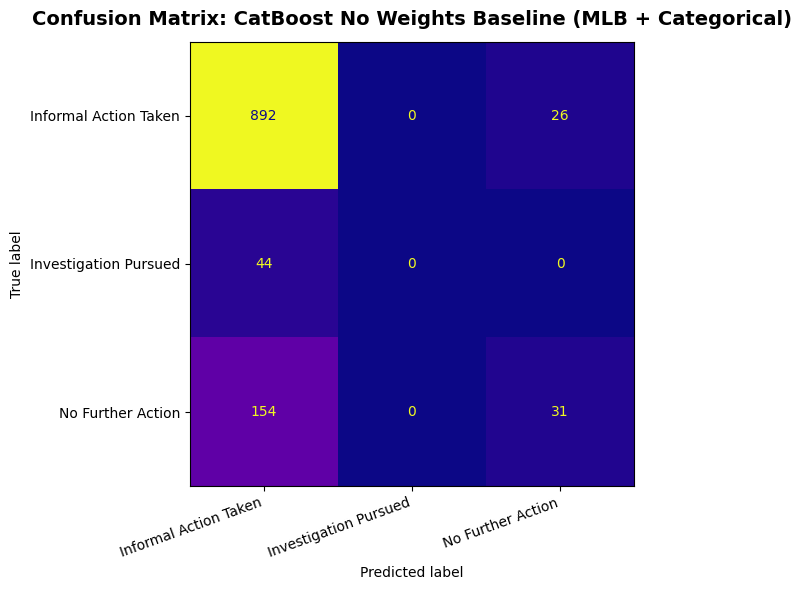

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                    892                      0   
Investigation Pursued                     44                      0   
No Further Action                        154                      0   

                       No Further Action  
Informal Action Taken                 26  
Investigation Pursued                  0  
No Further Action                     31  
Evaluating CatBoost Balanced Baseline (MLB + Categorical)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.95      0.76      0.85       918
Investigation Pursued       0.11      0.77      0.19        44
    No Further Action       0.47      0.24      0.32       185

             accuracy                           0.68      1147
            macro avg       0.51      0.59      0.45      1147
         weighted avg       0.84      0.68      0.74   

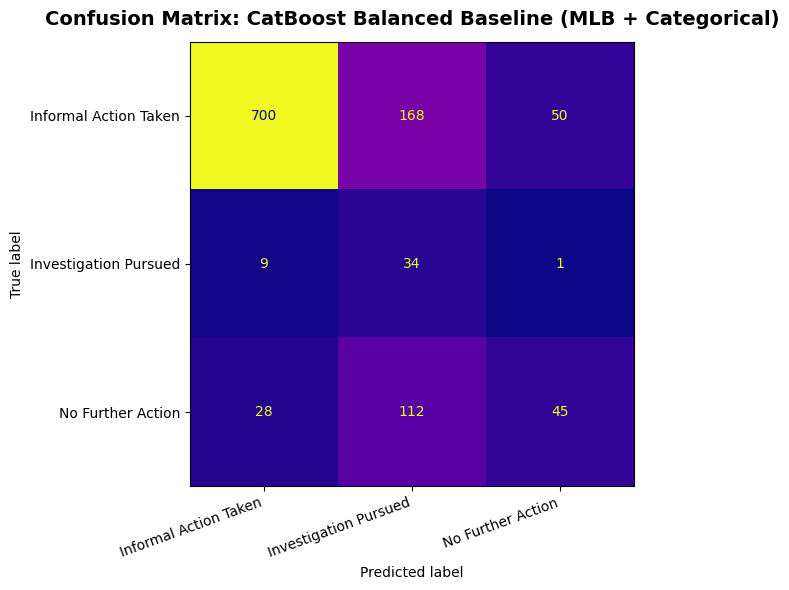

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                    700                    168   
Investigation Pursued                      9                     34   
No Further Action                         28                    112   

                       No Further Action  
Informal Action Taken                 50  
Investigation Pursued                  1  
No Further Action                     45  


In [8]:
mlb_cat_models = {}
mlb_cat_results = {}

mlb_cat_models["none"], mlb_cat_results["none"] = fit_catboost_classifier(
    "CatBoost No Weights Baseline (MLB + Categorical)",
    X_train_cat,
    y_train,
    X_val_cat,
    y_val,
    cat_feature_indices=cat_feature_indices,
    class_weights=None,
)

mlb_cat_models["baseline"], mlb_cat_results["baseline"] = fit_catboost_classifier(
    "CatBoost Balanced Baseline (MLB + Categorical)",
    X_train_cat,
    y_train,
    X_val_cat,
    y_val,
    cat_feature_indices=cat_feature_indices,
    class_weights="Balanced",
)

Evaluating CatBoost No Weights Baseline (MLB + OHE)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.82      0.97      0.89       918
Investigation Pursued       0.00      0.00      0.00        44
    No Further Action       0.57      0.18      0.27       185

             accuracy                           0.81      1147
            macro avg       0.46      0.38      0.39      1147
         weighted avg       0.75      0.81      0.76      1147

Accuracy: 0.8073
Macro F1 Score: 0.3872
Macro Precision: 0.4630
Macro Recall: 0.3837
Macro ROC AUC: 0.7587
Macro PR AUC: 0.4874
Log Loss: 0.8999

Per-Class F1 Scores:
	Informal Action Taken: F1 Score: 0.8899, ROC AUC: 0.7235, Brier Score: 0.2859
	Investigation Pursued: F1 Score: 0.0000, ROC AUC: 0.7733, Brier Score: 0.0942
	No Further Action: F1 Score: 0.2716, ROC AUC: 0.7792, Brier Score: 0.1462


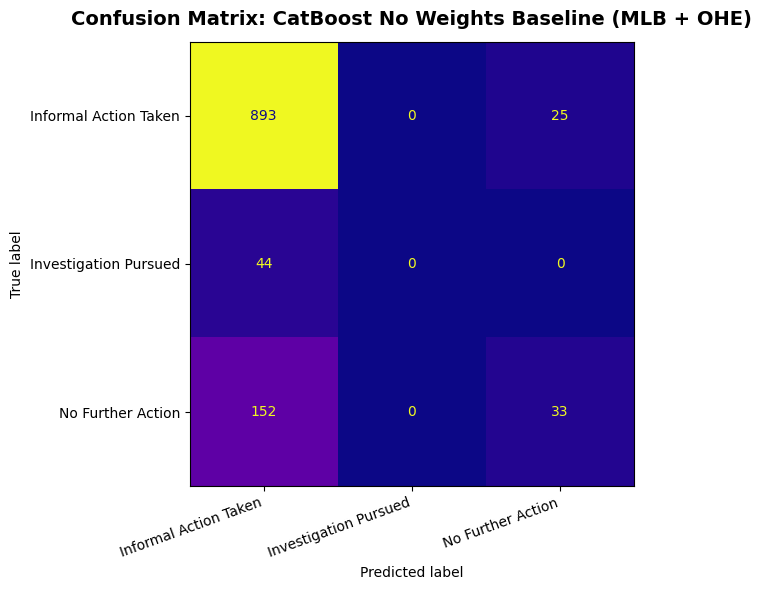

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                    893                      0   
Investigation Pursued                     44                      0   
No Further Action                        152                      0   

                       No Further Action  
Informal Action Taken                 25  
Investigation Pursued                  0  
No Further Action                     33  
Evaluating CatBoost Balanced Baseline (MLB + OHE)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.82      0.80      0.81       918
Investigation Pursued       0.16      0.59      0.25        44
    No Further Action       0.41      0.18      0.25       185

             accuracy                           0.70      1147
            macro avg       0.46      0.53      0.44      1147
         weighted avg       0.73      0.70      0.70      1147


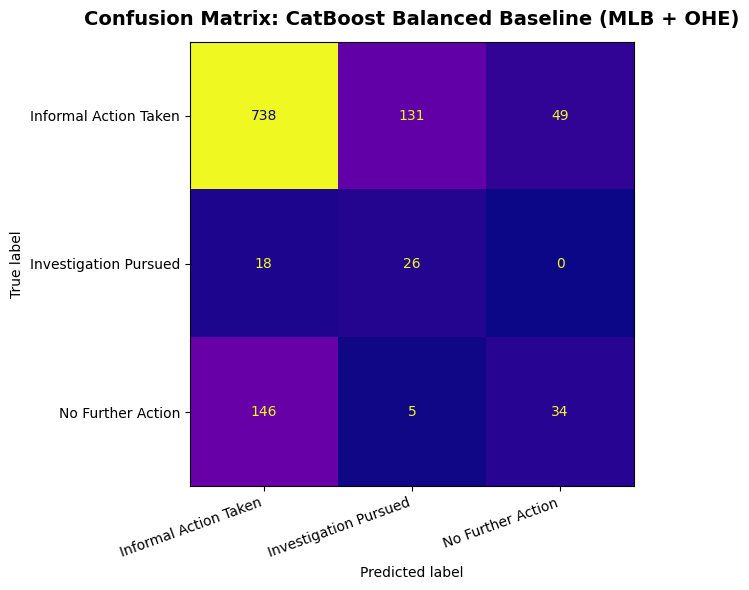

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                    738                    131   
Investigation Pursued                     18                     26   
No Further Action                        146                      5   

                       No Further Action  
Informal Action Taken                 49  
Investigation Pursued                  0  
No Further Action                     34  


In [9]:
mlb_ohe_models = {}
mlb_ohe_results = {}

mlb_ohe_models["none"], mlb_ohe_results["none"] = fit_catboost_classifier(
    "CatBoost No Weights Baseline (MLB + OHE)",
    X_train_ohe,
    y_train,
    X_val_ohe,
    y_val,
    cat_feature_indices=None,
    class_weights=None,
)

mlb_ohe_models["baseline"], mlb_ohe_results["baseline"] = fit_catboost_classifier(
    "CatBoost Balanced Baseline (MLB + OHE)",
    X_train_ohe,
    y_train,
    X_val_ohe,
    y_val,
    cat_feature_indices=None,
    class_weights="Balanced",
)

In [10]:
cb_encoding_comparison = compare_results_table(
    [mlb_cat_results["none"], mlb_cat_results["baseline"], mlb_ohe_results["none"], mlb_ohe_results["baseline"]],
    print_table=False
)
display(cb_encoding_comparison)

,model,accuracy,macro_f1,macro_precision,macro_recall,macro_roc_auc,macro_pr_auc,log_loss,f1_Informal Action Taken,roc_auc_Informal Action Taken,brier_Informal Action Taken,f1_Investigation Pursued,roc_auc_Investigation Pursued,brier_Investigation Pursued,f1_No Further Action,roc_auc_No Further Action,brier_No Further Action
0,CatBoost No Weights Baseline (MLB + Categorical),0.804708,0.381548,0.454069,0.379748,0.810489,0.520114,0.698745,0.8884,0.8368,0.1861,0.0000,0.7236,0.0619,0.2562,0.8711,0.1289
1,CatBoost Balanced Baseline (MLB + Categorical),0.679163,0.452050,0.508942,0.592833,0.721668,0.445170,0.878137,0.8459,0.8628,0.2343,0.1899,0.7975,0.1281,0.3203,0.5047,0.1495
2,CatBoost No Weights Baseline (MLB + OHE),0.807323,0.387163,0.462995,0.383715,0.758692,0.487374,0.899871,0.8899,0.7235,0.2859,0.0000,0.7733,0.0942,0.2716,0.7792,0.1462
3,CatBoost Balanced Baseline (MLB + OHE),0.695728,0.439049,0.462771,0.526205,0.668317,0.432168,1.073170,0.8110,0.6771,0.3675,0.2524,0.7694,0.1203,0.2537,0.5584,0.1617


In [11]:
tscv = TimeSeriesSplit(n_splits=CV_SPLITS)
param_grid = {
    "learning_rate": [0.03, 0.05, 0.07, 0.1],
    "depth": [6, 8, 10, 12],
    "l2_leaf_reg": [1, 3, 5, 7]
}

In [12]:
bw_tuned_model = CatBoostClassifier(
    iterations=2000,
    loss_function="MultiClass",
    random_state=RANDOM_STATE,
    cat_features=cat_feature_indices,
    early_stopping_rounds=50,
    eval_metric="TotalF1:average=Macro",
    auto_class_weights="Balanced",
    verbose=False
)

bw_grid_result = bw_tuned_model.grid_search(
    param_grid,
    X=X_train_cat,
    y=y_train,
    cv=tscv,
    stratified=False,
    refit=False,
    shuffle=False,
    verbose=False
)

c:\Users\elsad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:1262: UserWarning: The groups parameter is ignored by TimeSeriesSplit
  warnings.warn(


Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7045782603
bestIteration = 86

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7035455382
bestIteration = 75

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7011221012
bestIteration = 51

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7042759554
bestIteration = 72

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.700728389
bestIteration = 102

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7030623077
bestIteration = 78

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6979042775
bestIteration = 67

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7176232577
bestIteration = 117

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.700728389
bestIteration = 103

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7063833961
bestIteration = 108

Stopped 

In [13]:
nw_tuned_model = CatBoostClassifier(
    iterations=2000,
    loss_function="MultiClass",
    random_state=RANDOM_STATE,
    cat_features=cat_feature_indices,
    early_stopping_rounds=50,
    eval_metric="TotalF1:average=Macro",
    auto_class_weights=None,
    verbose=False
)

nw_grid_result = nw_tuned_model.grid_search(
    param_grid,
    X=X_train_cat,
    y=y_train,
    cv=tscv,
    stratified=False,
    refit=False,
    shuffle=False,
    verbose=False
)

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4386304617
bestIteration = 64

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4565685599
bestIteration = 148

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4624220829
bestIteration = 166

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4682495453
bestIteration = 138

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.441480434
bestIteration = 114

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4591388642
bestIteration = 263

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4661787352
bestIteration = 117

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4616460225
bestIteration = 115

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.441480434
bestIteration = 139

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.439703154
bestIteration = 62

Stopp

In [14]:
print("\nBest parameters found:")
for key, value in bw_grid_result["params"].items():
    print(f"\t{key}: {value}")

bw_cv_curve = pd.DataFrame(bw_grid_result["cv_results"])
bw_best_iteration = bw_cv_curve["test-TotalF1:average=Macro-mean"].idxmax()
bw_train_f1 = bw_cv_curve.loc[bw_best_iteration, "train-TotalF1:average=Macro-mean"]
bw_test_f1  = bw_cv_curve.loc[bw_best_iteration, "test-TotalF1:average=Macro-mean"]
bw_test_std = bw_cv_curve.loc[bw_best_iteration, "test-TotalF1:average=Macro-std"]

print(f"\nCV diagnostics for best combination:")
print(f"\tBest iteration: {bw_best_iteration} of {len(bw_cv_curve)} total")
print(f"\tTrain F1: {bw_train_f1:.4f}")
print(f"\tTest F1: {bw_test_f1:.4f} (std across folds: {bw_test_std:.4f})")
print(f"\tTrain-test gap: {bw_train_f1 - bw_test_f1:.4f}")


Best parameters found:
	depth: 6
	learning_rate: 0.1
	l2_leaf_reg: 3

CV diagnostics for best combination:
	Best iteration: 55 of 147 total
	Train F1: 0.7181
	Test F1: 0.5493 (std across folds: 0.0685)
	Train-test gap: 0.1689


In [15]:
print("\nBest parameters found:")
for key, value in nw_grid_result["params"].items():
    print(f"\t{key}: {value}")

nw_cv_curve = pd.DataFrame(nw_grid_result["cv_results"])
nw_best_iteration = nw_cv_curve["test-TotalF1:average=Macro-mean"].idxmax()
nw_train_f1 = nw_cv_curve.loc[nw_best_iteration, "train-TotalF1:average=Macro-mean"]
nw_test_f1  = nw_cv_curve.loc[nw_best_iteration, "test-TotalF1:average=Macro-mean"]
nw_test_std = nw_cv_curve.loc[nw_best_iteration, "test-TotalF1:average=Macro-std"]

print(f"\nCV diagnostics for best combination:")
print(f"\tBest iteration: {nw_best_iteration} of {len(nw_cv_curve)} total")
print(f"\tTrain F1: {nw_train_f1:.4f}")
print(f"\tTest F1: {nw_test_f1:.4f} (std across folds: {nw_test_std:.4f})")
print(f"\tTrain-test gap: {nw_train_f1 - nw_test_f1:.4f}")


Best parameters found:
	depth: 10
	learning_rate: 0.07
	l2_leaf_reg: 1

CV diagnostics for best combination:
	Best iteration: 138 of 201 total
	Train F1: 0.7275
	Test F1: 0.4332 (std across folds: 0.0576)
	Train-test gap: 0.2943


Evaluating CatBoost Tuned (Balanced MLB + CAT)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.95      0.74      0.83       918
Investigation Pursued       0.11      0.75      0.20        44
    No Further Action       0.48      0.35      0.41       185

             accuracy                           0.68      1147
            macro avg       0.51      0.61      0.48      1147
         weighted avg       0.84      0.68      0.74      1147

Accuracy: 0.6800
Macro F1 Score: 0.4784
Macro Precision: 0.5145
Macro Recall: 0.6148
Macro ROC AUC: 0.7494
Macro PR AUC: 0.4672
Log Loss: 0.8301

Per-Class F1 Scores:
	Informal Action Taken: F1 Score: 0.8337, ROC AUC: 0.8552, Brier Score: 0.2172
	Investigation Pursued: F1 Score: 0.1953, ROC AUC: 0.8097, Brier Score: 0.1216
	No Further Action: F1 Score: 0.4062, ROC AUC: 0.5833, Brier Score: 0.1458


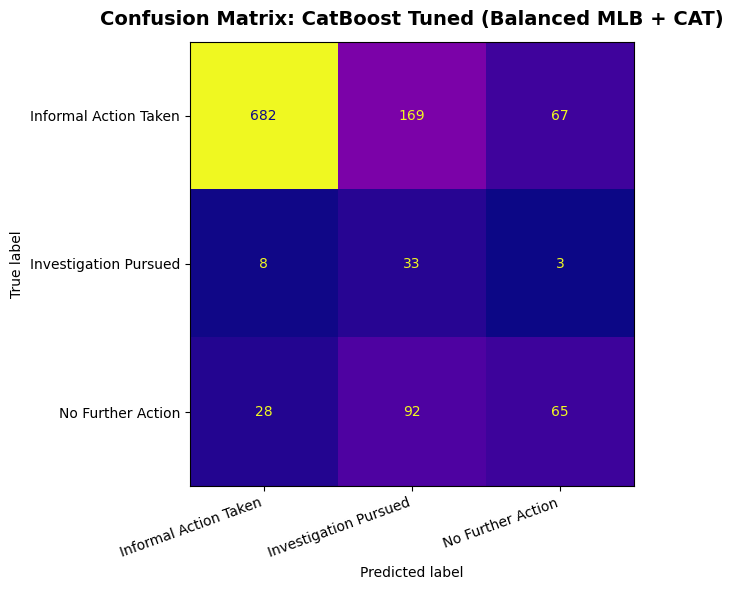

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                    682                    169   
Investigation Pursued                      8                     33   
No Further Action                         28                     92   

                       No Further Action  
Informal Action Taken                 67  
Investigation Pursued                  3  
No Further Action                     65  

Final CatBoost model, Best iteration found: 170


In [16]:
balanced_catboost_tuned, balanced_catboost_tuned_results = fit_catboost_classifier(
    "CatBoost Tuned (Balanced MLB + CAT)",
    X_train_cat,
    y_train,
    X_val_cat,
    y_val,
    cat_feature_indices=cat_feature_indices,
    class_weights="Balanced",
    hyperparameters= bw_grid_result["params"]
)

print(f"\nFinal CatBoost model, Best iteration found: {balanced_catboost_tuned.get_best_iteration()}")

Feature importance (grouped by original feature):
original_feature
incident_type                38.453387
no_data_subjects_affected    16.279875
time_taken_to_report         13.156034
data_subject_type            11.041355
data_type                    10.647929
incident_category            10.421419

Top 15 raw features (including individual MLB sub-columns):
                                              feature  importance          original_feature
                                        incident_type   38.453387             incident_type
                            no_data_subjects_affected   16.279875 no_data_subjects_affected
                                 time_taken_to_report   13.156034      time_taken_to_report
                                    incident_category   10.421419         incident_category
                data_type__Basic personal identifiers    3.912910                 data_type
                               data_type__Health data    2.756135                 data

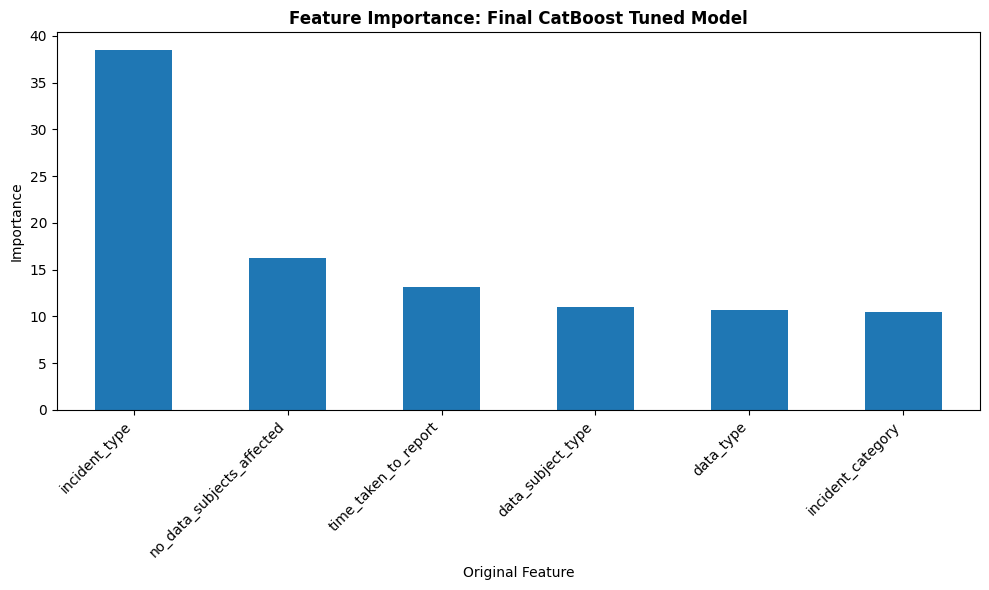

,feature,importance,original_feature
0,incident_category,10.421419,incident_category
1,incident_type,38.453387,incident_type
2,no_data_subjects_affected,16.279875,no_data_subjects_affected
3,time_taken_to_report,13.156034,time_taken_to_report
4,data_subject_type__Children,2.390683,data_subject_type
5,data_subject_type__Customers or prospective cu...,0.699995,data_subject_type
6,data_subject_type__Employees,2.124250,data_subject_type
7,data_subject_type__Patients,2.365713,data_subject_type
8,data_subject_type__Students,0.004675,data_subject_type
9,data_subject_type__Subscribers,0.032543,data_subject_type


In [17]:
importances = balanced_catboost_tuned.get_feature_importance()
importance_df = pd.DataFrame({
    "feature": X_train_cat.columns,
    "importance": importances,
})
importance_df["original_feature"] = importance_df["feature"].apply(
    lambda c: get_original_feature(c, CATEGORICAL_COLS)
)
importance_grouped = importance_df.groupby("original_feature")["importance"].sum().sort_values(ascending=False)

print("Feature importance (grouped by original feature):")
print(importance_grouped.to_string())

print("\nTop 15 raw features (including individual MLB sub-columns):")
print(importance_df.sort_values("importance", ascending=False).head(15).to_string(index=False))

plot_feature_importance(
    importances,
    list(X_train_cat.columns),
    title="Feature Importance: Final CatBoost Tuned Model",
    categorical_cols=CATEGORICAL_COLS,
    group_by_original_feature=True,
)


Combined feature importance (built-in + permutation, grouped by original feature):
                           built_in  permutation
original_feature                                
incident_type                 38.45        25.97
no_data_subjects_affected     16.28        13.40
time_taken_to_report          13.16        14.31
data_subject_type             11.04         0.75
data_type                     10.65        30.86
incident_category             10.42        14.70


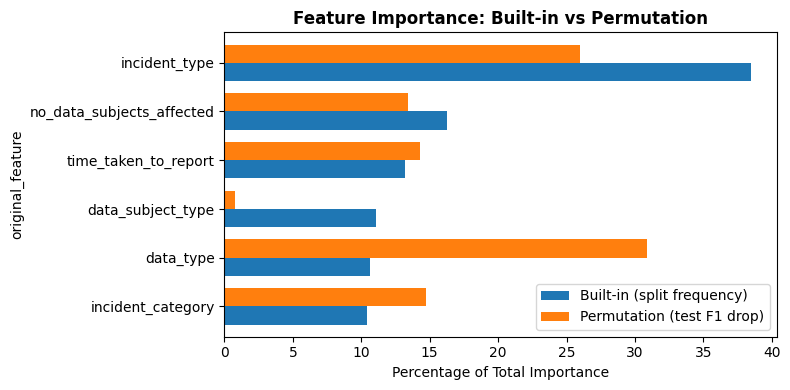


Raw permutation importance (per encoded column, top 15):
	incident_type, Mean drop: +0.0601, Std: 0.0069
	data_type__Health data, Mean drop: +0.0393, Std: 0.0052
	incident_category, Mean drop: +0.0340, Std: 0.0076
	time_taken_to_report, Mean drop: +0.0331, Std: 0.0069
	no_data_subjects_affected, Mean drop: +0.0310, Std: 0.0051
	data_type__Unknown, Mean drop: +0.0310, Std: 0.0043
	data_subject_type__Patients, Mean drop: +0.0041, Std: 0.0014
	data_type__Basic personal identifiers, Mean drop: +0.0031, Std: 0.0033
	data_subject_type__Employees, Mean drop: +0.0016, Std: 0.0019
	data_subject_type__Unknown, Mean drop: +0.0015, Std: 0.0007
	data_type__Data revealing racial or ethnic origin, Mean drop: +0.0011, Std: 0.0017
	data_subject_type__Users, Mean drop: +0.0007, Std: 0.0015
	data_type__Sex life data, Mean drop: +0.0006, Std: 0.0009
	data_type__Identification data, Mean drop: +0.0002, Std: 0.0011
	data_type__Gender Reassignment Data, Mean drop: +0.0001, Std: 0.0005


In [18]:
permutation_results = permutation_importance(
    balanced_catboost_tuned,
    X_val_cat,
    y_val,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1,
    scoring="f1_macro"
)

permutation_importance_df = pd.DataFrame({
    "feature": X_train_cat.columns,
    "importance_mean": permutation_results["importances_mean"],
    "importance_std": permutation_results["importances_std"]
})
permutation_importance_df["original_feature"] = permutation_importance_df["feature"].apply(
    lambda c: get_original_feature(c, CATEGORICAL_COLS)
)
permutation_grouped = permutation_importance_df.groupby("original_feature")["importance_mean"].sum().sort_values(ascending=False)

combined_importance = pd.DataFrame({
    "built_in": importance_grouped,
    "permutation": permutation_grouped
}).sort_values("built_in", ascending=False)

combined_importance_percent = combined_importance.div(combined_importance.sum()).mul(100).round(2)
print("\nCombined feature importance (built-in + permutation, grouped by original feature):")
print(combined_importance_percent.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
combined_importance_percent.iloc[::-1].plot(kind="barh", ax=ax, width=0.75)
ax.set_title("Feature Importance: Built-in vs Permutation", fontweight="bold")
ax.set_xlabel("Percentage of Total Importance")
ax.legend(["Built-in (split frequency)", "Permutation (test F1 drop)"])
plt.tight_layout()
plt.show()

print(f"\nRaw permutation importance (per encoded column, top 15):")
top_perm = permutation_importance_df.sort_values("importance_mean", ascending=False).head(15)
for _, row in top_perm.iterrows():
    print(f"\t{row['feature']}, Mean drop: {row['importance_mean']:+.4f}, Std: {row['importance_std']:.4f}")


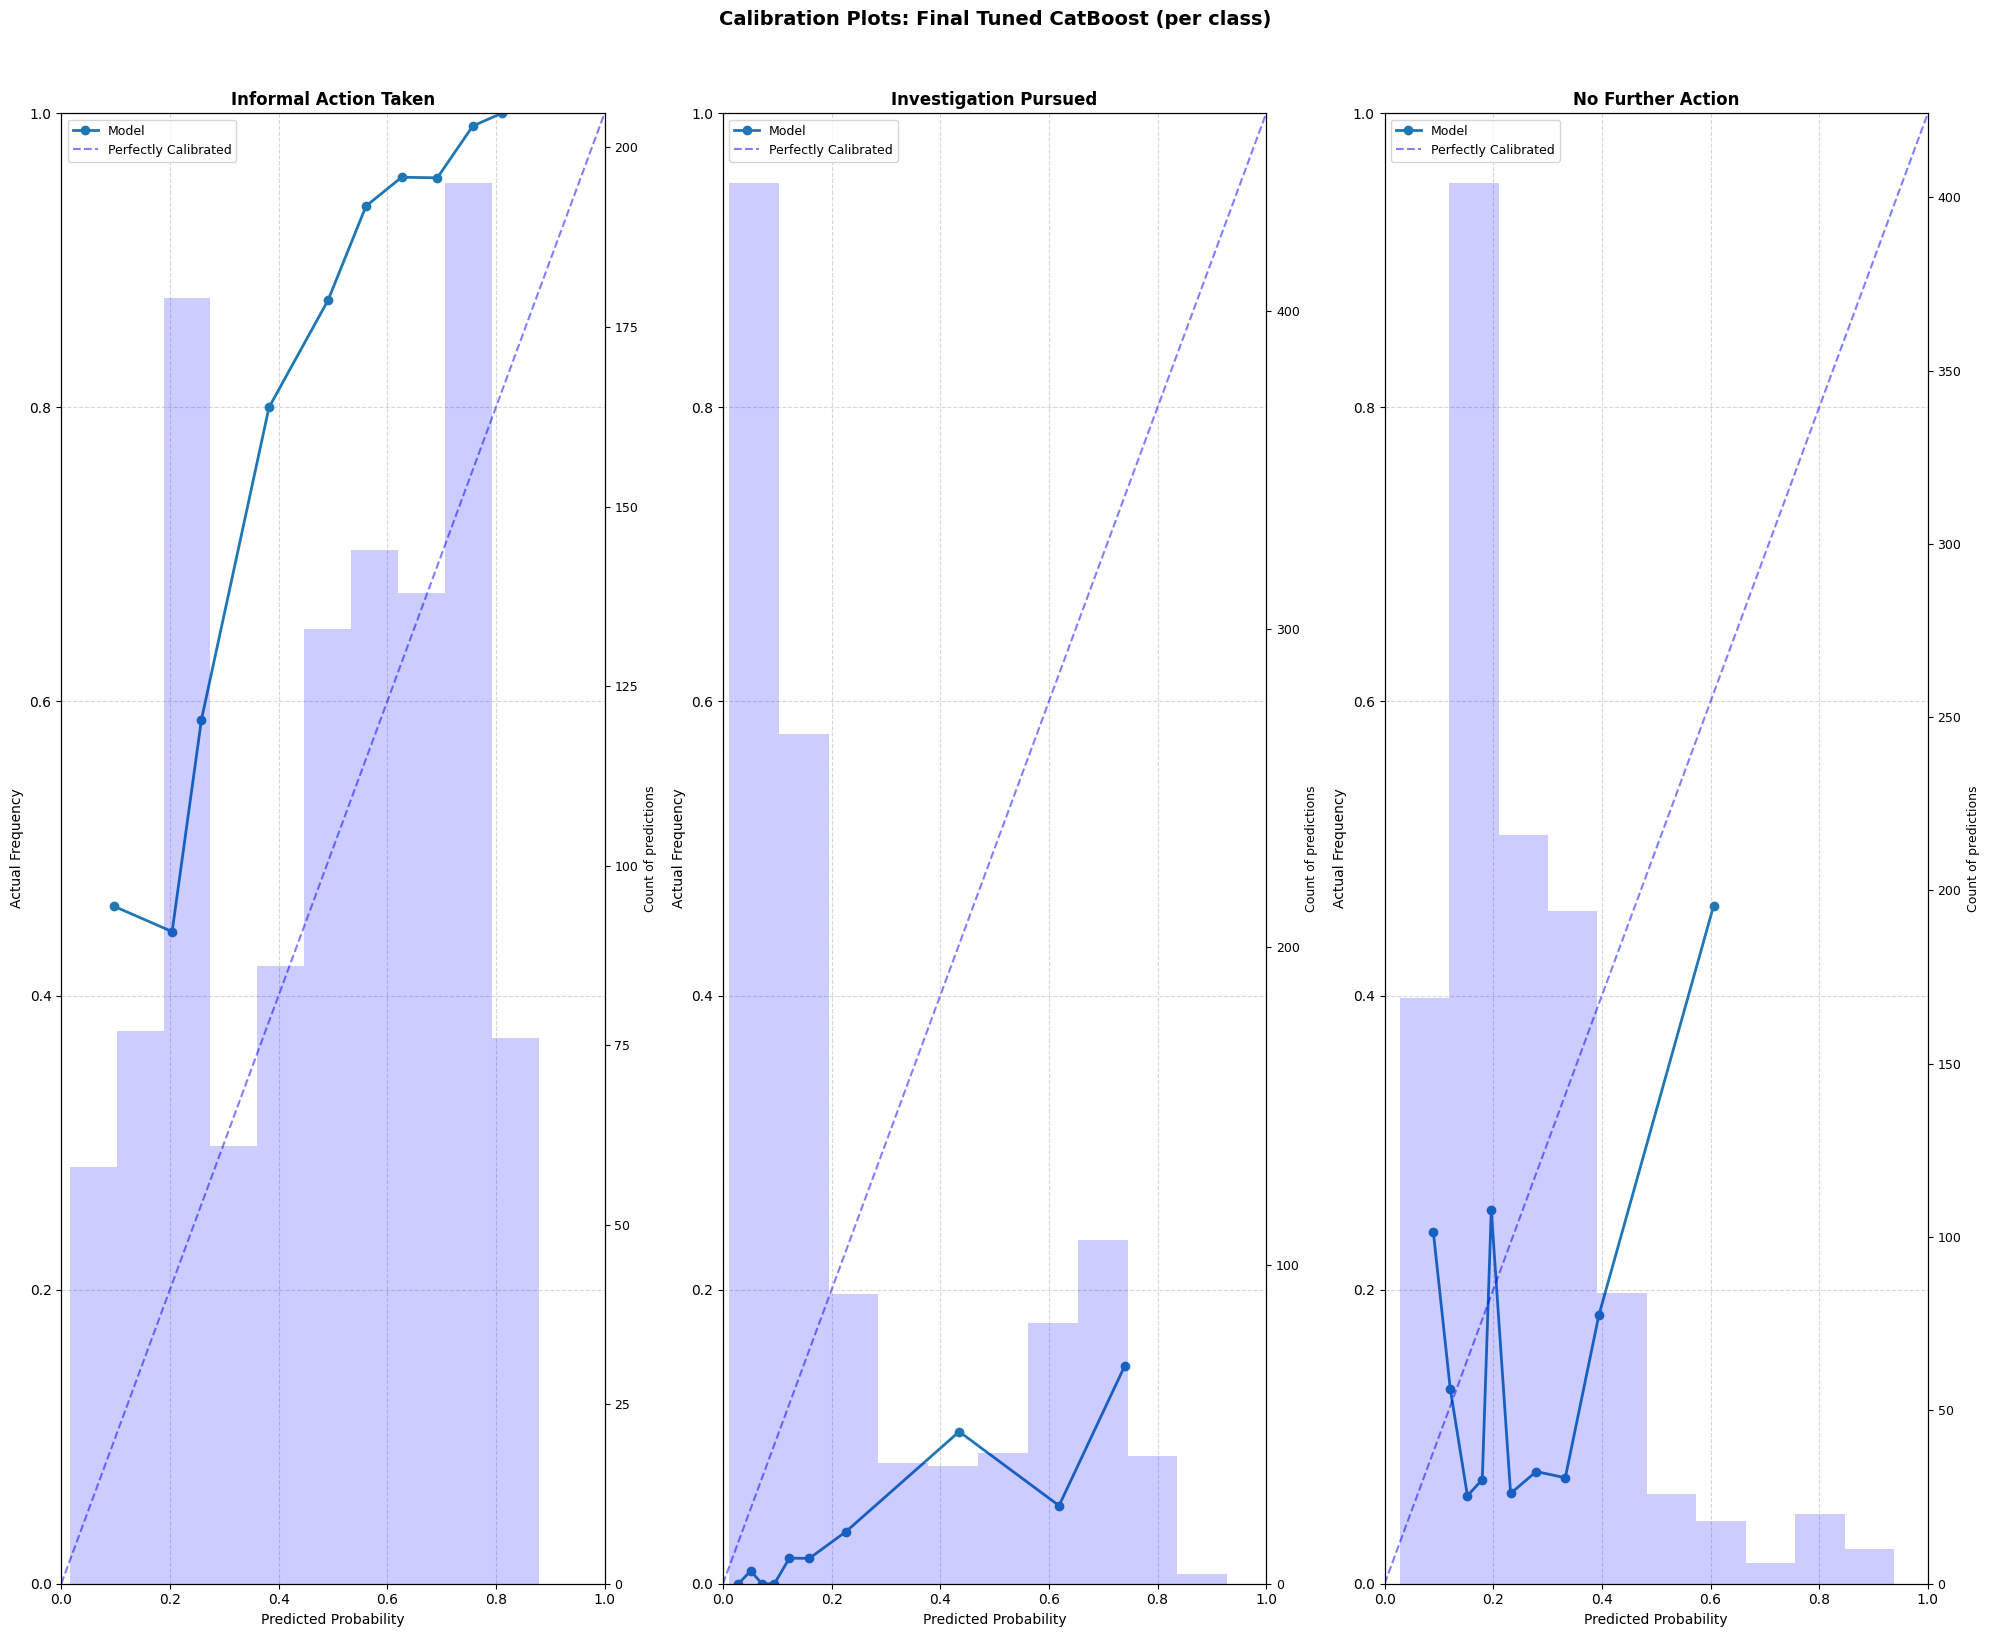

Brier score per class:
	Informal Action Taken: 0.2172
	Investigation Pursued: 0.1216
	No Further Action: 0.1458


In [19]:
y_proba = balanced_catboost_tuned.predict_proba(X_val_cat)
proba_class_order = list(balanced_catboost_tuned.classes_)
proba_aligned = np.column_stack([y_proba[:, proba_class_order.index(c)] for c in CLASS_LABELS])

plot_calibration_curve(
    y_val, proba_aligned, CLASS_LABELS,
    title="Calibration Plots: Final Tuned CatBoost (per class)",
)

# Quantitative calibration summary, Brier score per class
print("Brier score per class:")
for i, class_name in enumerate(CLASS_LABELS):
    y_true_bin = (y_val.values == class_name).astype(int)
    brier = brier_score_loss(y_true_bin, proba_aligned[:, i])
    print(f"\t{class_name}: {brier:.4f}")

Evaluating CatBoost Tuned (No Weights MLB + CAT)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.82      0.98      0.89       918
Investigation Pursued       0.00      0.00      0.00        44
    No Further Action       0.57      0.16      0.25       185

             accuracy                           0.81      1147
            macro avg       0.46      0.38      0.38      1147
         weighted avg       0.75      0.81      0.75      1147

Accuracy: 0.8065
Macro F1 Score: 0.3785
Macro Precision: 0.4620
Macro Recall: 0.3776
Macro ROC AUC: 0.8027
Macro PR AUC: 0.5144
Log Loss: 0.6186

Per-Class F1 Scores:
	Informal Action Taken: F1 Score: 0.8898, ROC AUC: 0.8353, Brier Score: 0.1491
	Investigation Pursued: F1 Score: 0.0000, ROC AUC: 0.7228, Brier Score: 0.0504
	No Further Action: F1 Score: 0.2458, ROC AUC: 0.8499, Brier Score: 0.1238


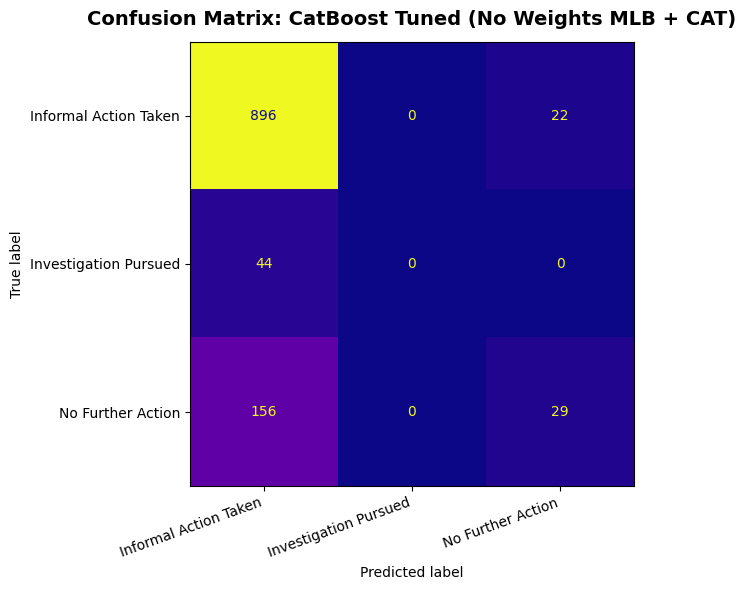

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                    896                      0   
Investigation Pursued                     44                      0   
No Further Action                        156                      0   

                       No Further Action  
Informal Action Taken                 22  
Investigation Pursued                  0  
No Further Action                     29  

Final CatBoost model, Best iteration found: 17


In [20]:
# CHECKING WITH NO WEIGHTS
unweighted_catboost_tuned, unweighted_catboost_tuned_results = fit_catboost_classifier(
    "CatBoost Tuned (No Weights MLB + CAT)",
    X_train_cat,
    y_train,
    X_val_cat,
    y_val,
    cat_feature_indices=cat_feature_indices,
    class_weights=None,
    hyperparameters= nw_grid_result["params"]
)

print(f"\nFinal CatBoost model, Best iteration found: {unweighted_catboost_tuned.get_best_iteration()}")

Feature importance (grouped by original feature):
original_feature
incident_category            51.313856
incident_type                22.520265
no_data_subjects_affected    10.511646
data_type                     7.929138
data_subject_type             4.726723
time_taken_to_report          2.998372

Top 15 raw features (including individual MLB sub-columns):
                                              feature  importance          original_feature
                                    incident_category   51.313856         incident_category
                                        incident_type   22.520265             incident_type
                            no_data_subjects_affected   10.511646 no_data_subjects_affected
                               data_type__Health data    4.451262                 data_type
                                 time_taken_to_report    2.998372      time_taken_to_report
                         data_subject_type__Employees    2.509153         data_subject

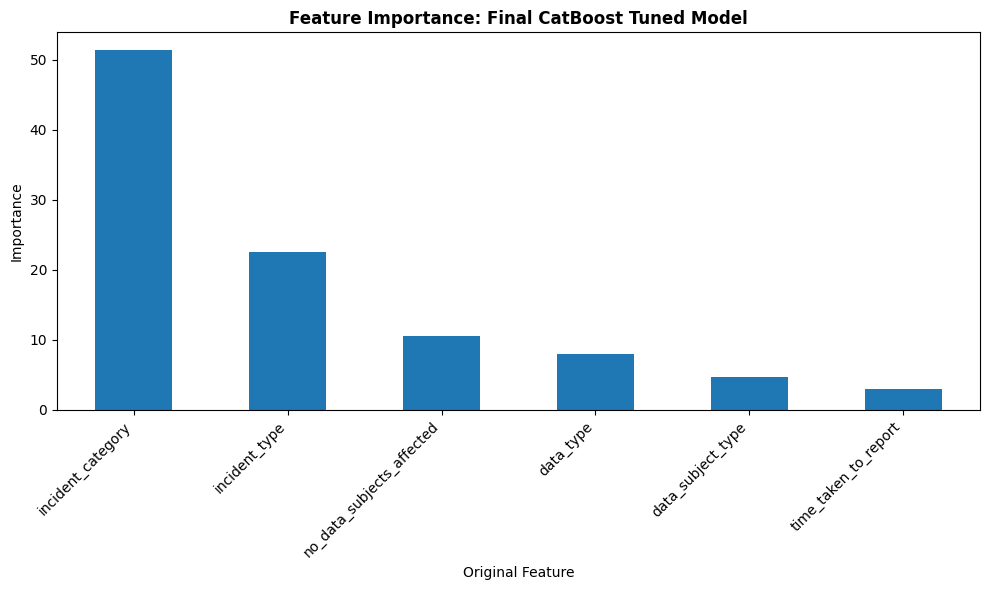

,feature,importance,original_feature
0,incident_category,51.313856,incident_category
1,incident_type,22.520265,incident_type
2,no_data_subjects_affected,10.511646,no_data_subjects_affected
3,time_taken_to_report,2.998372,time_taken_to_report
4,data_subject_type__Children,0.000000,data_subject_type
5,data_subject_type__Customers or prospective cu...,0.360029,data_subject_type
6,data_subject_type__Employees,2.509153,data_subject_type
7,data_subject_type__Patients,1.399002,data_subject_type
8,data_subject_type__Students,0.068892,data_subject_type
9,data_subject_type__Subscribers,0.092702,data_subject_type


In [21]:
importances = unweighted_catboost_tuned.get_feature_importance()
importance_df = pd.DataFrame({
    "feature": X_train_cat.columns,
    "importance": importances,
})
importance_df["original_feature"] = importance_df["feature"].apply(
    lambda c: get_original_feature(c, CATEGORICAL_COLS)
)
importance_grouped = importance_df.groupby("original_feature")["importance"].sum().sort_values(ascending=False)

print("Feature importance (grouped by original feature):")
print(importance_grouped.to_string())

print("\nTop 15 raw features (including individual MLB sub-columns):")
print(importance_df.sort_values("importance", ascending=False).head(15).to_string(index=False))

plot_feature_importance(
    importances,
    list(X_train_cat.columns),
    title="Feature Importance: Final CatBoost Tuned Model",
    categorical_cols=CATEGORICAL_COLS,
    group_by_original_feature=True,
)


Combined feature importance (built-in + permutation, grouped by original feature):
                           built_in  permutation
original_feature                                
incident_category             51.31        43.71
incident_type                 22.52        13.27
no_data_subjects_affected     10.51        41.42
data_type                      7.93         0.12
data_subject_type              4.73         3.15
time_taken_to_report           3.00        -1.67


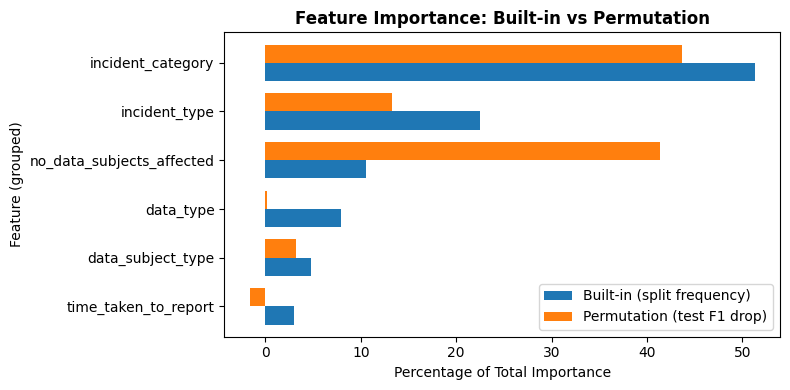


Raw permutation importance (per encoded column, top 15):
	incident_category, Mean drop: +0.0476, Std: 0.0095
	no_data_subjects_affected, Mean drop: +0.0451, Std: 0.0092
	incident_type, Mean drop: +0.0145, Std: 0.0045
	data_subject_type__Patients, Mean drop: +0.0015, Std: 0.0031
	data_subject_type__Employees, Mean drop: +0.0013, Std: 0.0012
	data_type__Health data, Mean drop: +0.0012, Std: 0.0010
	data_subject_type__Customers or prospective customers, Mean drop: +0.0005, Std: 0.0000
	data_type__Economic and financial data, Mean drop: +0.0005, Std: 0.0000
	data_type__Basic personal identifiers, Mean drop: +0.0003, Std: 0.0003
	data_subject_type__Users, Mean drop: +0.0001, Std: 0.0002
	data_type__Location data, Mean drop: +0.0001, Std: 0.0002
	data_subject_type__Students, Mean drop: +0.0000, Std: 0.0000
	data_subject_type__Children, Mean drop: +0.0000, Std: 0.0000
	data_type__Identification data, Mean drop: +0.0000, Std: 0.0000
	data_subject_type__Vulnerable adults, Mean drop: +0.0000, S

In [22]:
permutation_results = permutation_importance(
    unweighted_catboost_tuned,
    X_val_cat,
    y_val,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1,
    scoring="f1_macro"
)

permutation_importance_df = pd.DataFrame({
    "feature": X_train_cat.columns,
    "importance_mean": permutation_results["importances_mean"],
    "importance_std": permutation_results["importances_std"]
})
permutation_importance_df["original_feature"] = permutation_importance_df["feature"].apply(
    lambda c: get_original_feature(c, CATEGORICAL_COLS)
)
permutation_grouped = permutation_importance_df.groupby("original_feature")["importance_mean"].sum().sort_values(ascending=False)

combined_importance = pd.DataFrame({
    "built_in": importance_grouped,
    "permutation": permutation_grouped
}).sort_values("built_in", ascending=False)

combined_importance_percent = combined_importance.div(combined_importance.sum()).mul(100).round(2)
print("\nCombined feature importance (built-in + permutation, grouped by original feature):")
print(combined_importance_percent.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
combined_importance_percent.iloc[::-1].plot(kind="barh", ax=ax, width=0.75)
ax.set_title("Feature Importance: Built-in vs Permutation", fontweight="bold")
ax.set_xlabel("Percentage of Total Importance")
ax.set_ylabel("Feature (grouped)")
ax.legend(["Built-in (split frequency)", "Permutation (test F1 drop)"])
plt.tight_layout()
plt.show()

print(f"\nRaw permutation importance (per encoded column, top 15):")
top_perm = permutation_importance_df.sort_values("importance_mean", ascending=False).head(15)
for _, row in top_perm.iterrows():
    print(f"\t{row['feature']}, Mean drop: {row['importance_mean']:+.4f}, Std: {row['importance_std']:.4f}")

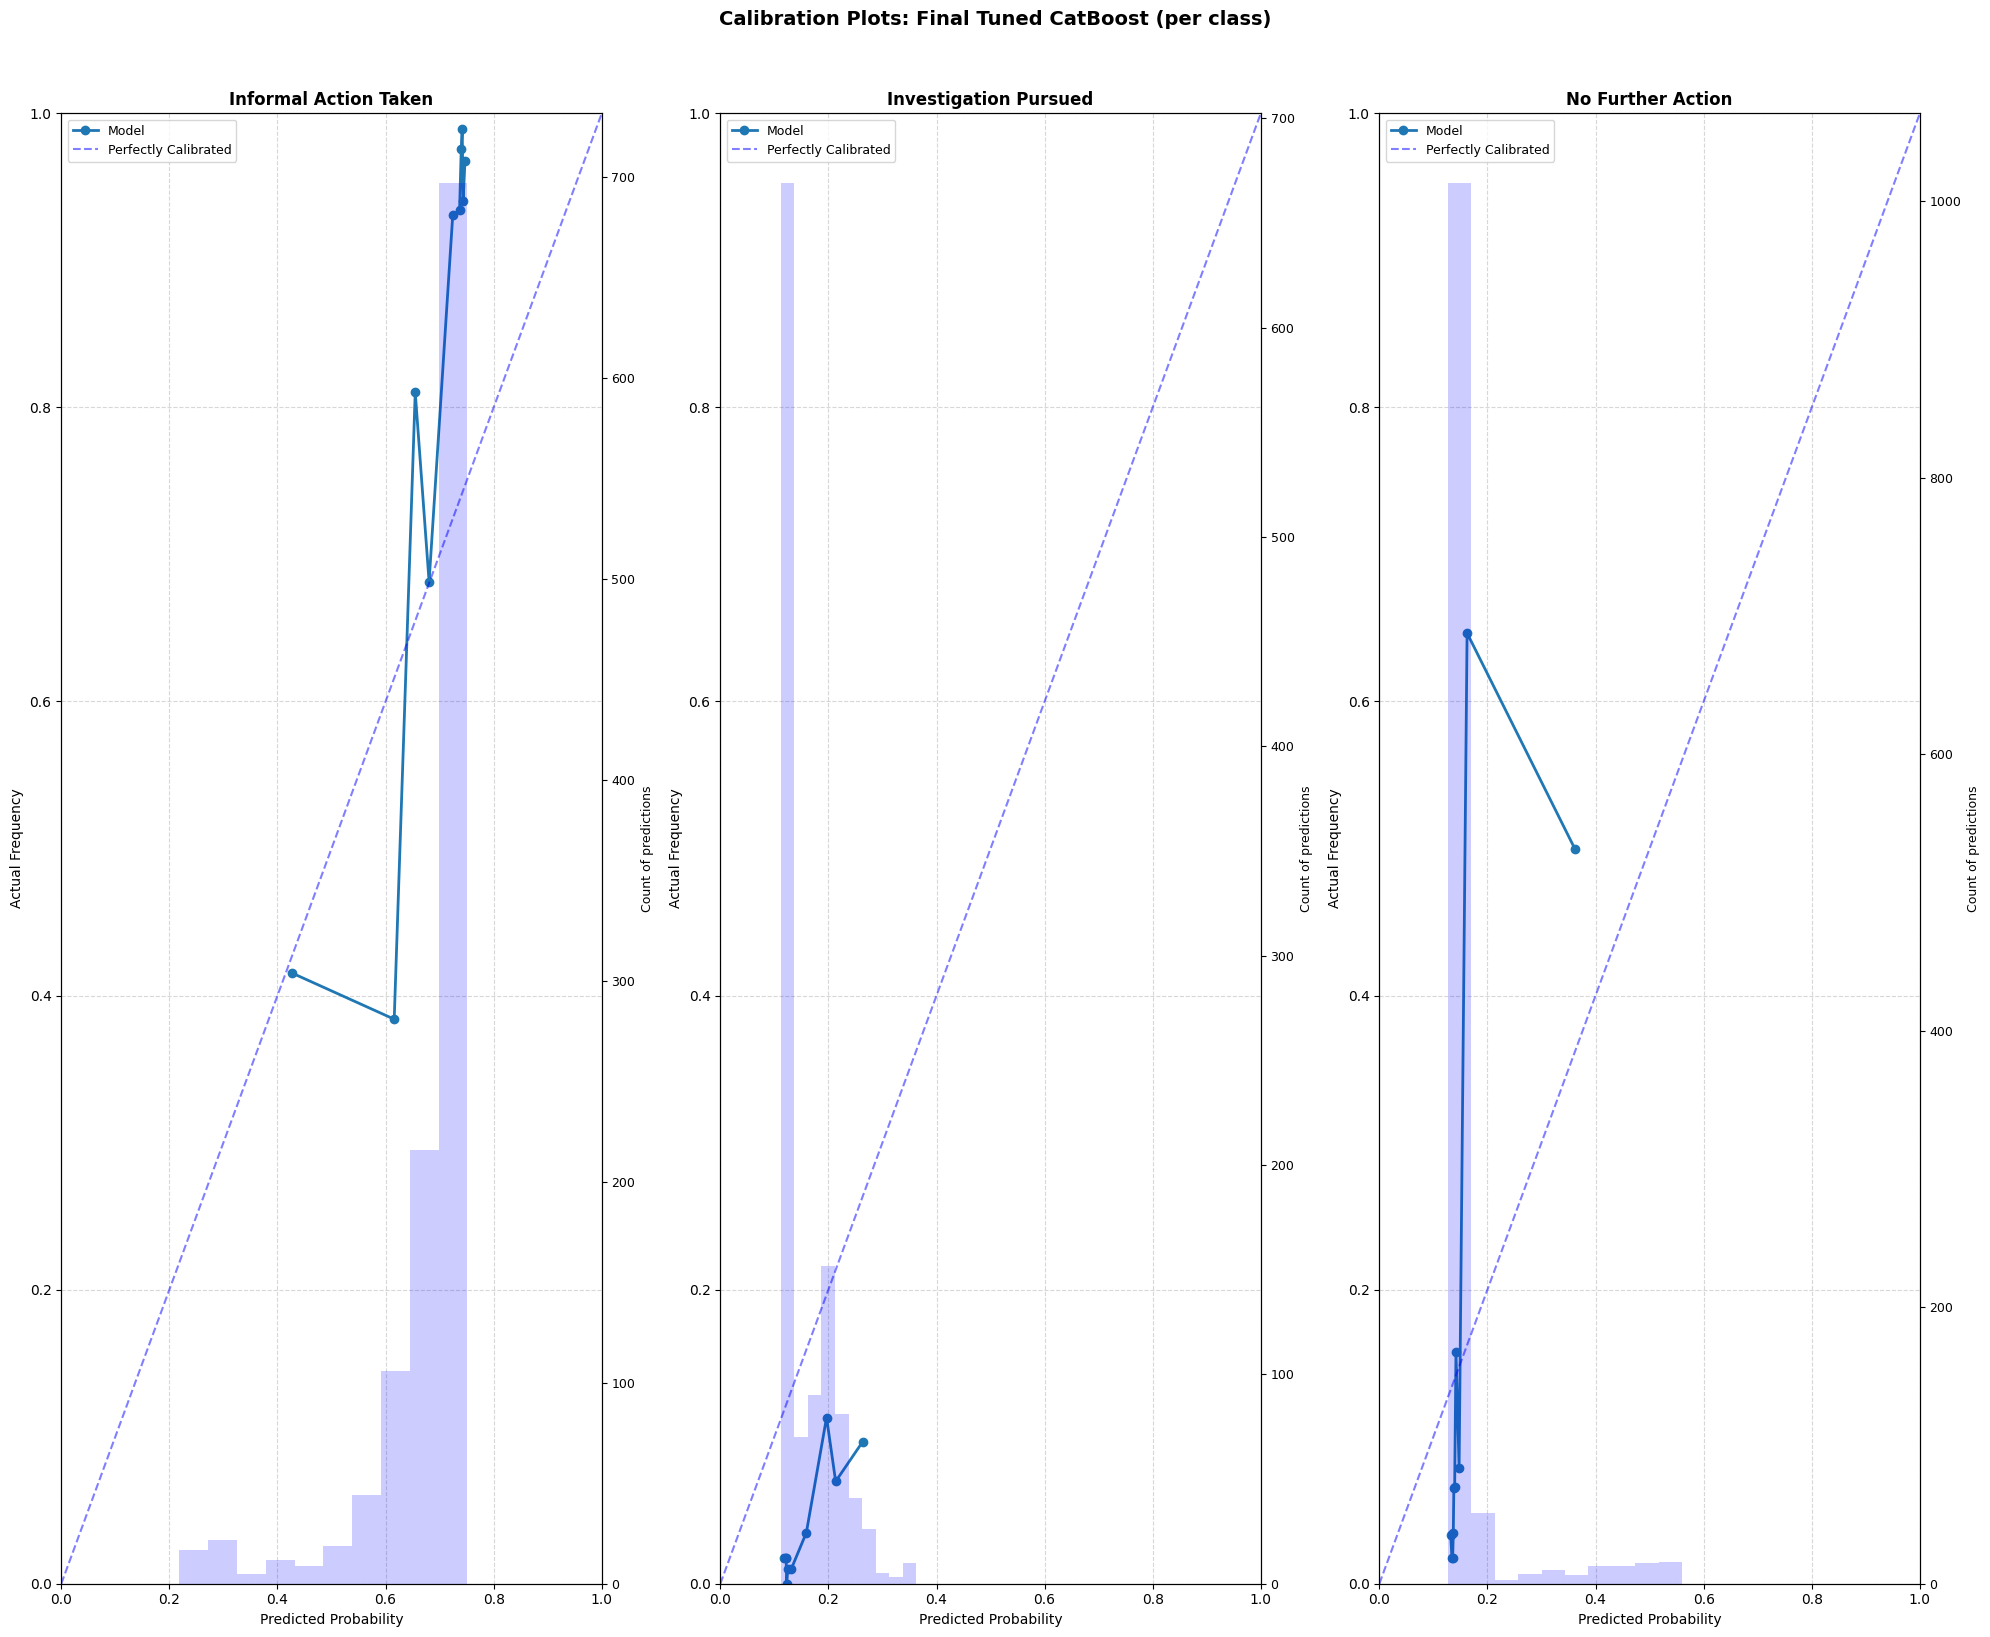

Brier score per class:
	Informal Action Taken: 0.1491
	Investigation Pursued: 0.0504
	No Further Action: 0.1238


In [23]:
y_proba = unweighted_catboost_tuned.predict_proba(X_val_cat)
proba_class_order = list(unweighted_catboost_tuned.classes_)
proba_aligned = np.column_stack([y_proba[:, proba_class_order.index(c)] for c in CLASS_LABELS])

plot_calibration_curve(
    y_val, proba_aligned, CLASS_LABELS,
    title="Calibration Plots: Final Tuned CatBoost (per class)",
)

# Quantitative calibration summary, Brier score per class
print("Brier score per class:")
for i, class_name in enumerate(CLASS_LABELS):
    y_true_bin = (y_val.values == class_name).astype(int)
    brier = brier_score_loss(y_true_bin, proba_aligned[:, i])
    print(f"\t{class_name}: {brier:.4f}")

Evaluating Final CatBoost Tuned: Test Evaluation (No Weights MLB + CAT)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.96      0.98      0.97      1836
Investigation Pursued       0.00      0.00      0.00        30
    No Further Action       0.41      0.39      0.40        72

             accuracy                           0.94      1938
            macro avg       0.46      0.46      0.46      1938
         weighted avg       0.93      0.94      0.94      1938

Accuracy: 0.9438
Macro F1 Score: 0.4573
Macro Precision: 0.4583
Macro Recall: 0.4566
Macro ROC AUC: 0.7411
Macro PR AUC: 0.4306
Log Loss: 0.4236

Per-Class F1 Scores:
	Informal Action Taken: F1 Score: 0.9719, ROC AUC: 0.7709, Brier Score: 0.1084
	Investigation Pursued: F1 Score: 0.0000, ROC AUC: 0.6347, Brier Score: 0.0332
	No Further Action: F1 Score: 0.4000, ROC AUC: 0.8176, Brier Score: 0.0461


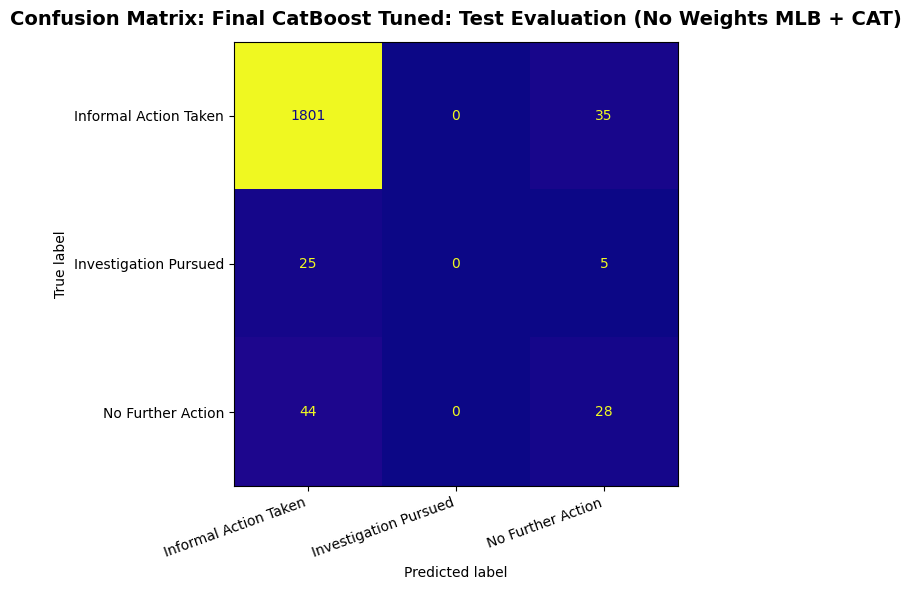

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                   1801                      0   
Investigation Pursued                     25                      0   
No Further Action                         44                      0   

                       No Further Action  
Informal Action Taken                 35  
Investigation Pursued                  5  
No Further Action                     28  


In [32]:
final_catboost_params = nw_grid_result["params"]
final_catboost_class_weights = None

final_catboost_kwargs = {
    "iterations": 2000,
    "loss_function": "MultiClass",
    "random_state": RANDOM_STATE,
    "cat_features": cat_feature_indices,
    "early_stopping_rounds": 50,
    "eval_metric": "TotalF1:average=Macro",
    "verbose": False
}

final_catboost_kwargs.update(final_catboost_params)

if final_catboost_class_weights == "Balanced":
    final_catboost_kwargs["auto_class_weights"] = "Balanced"
else:
    final_catboost_kwargs["auto_class_weights"] = None
    
final_catboost_model = CatBoostClassifier(**final_catboost_kwargs)
final_catboost_model.fit(X_train_cat, y_train, eval_set=(X_val_cat, y_val))
final_catboost_results = evaluate_classification_model(
    model_name="Final CatBoost Tuned: Test Evaluation (No Weights MLB + CAT)",
    model=final_catboost_model,
    X_eval=X_test_cat,
    y_eval=y_test
)
best_iteration = final_catboost_model.get_best_iteration()

In [33]:
# Capture the best iteration from the train/ val fit before retraining
best_iter = final_catboost_model.get_best_iteration()
print(f"Best iteration from train/ val fit: {best_iter}")

# Build the full feature matrix on all data
X_full, _ = build_mlb_cat_matrix(df, mlb_encoder)
y_full = df[TARGET_COL].reset_index(drop=True)

assert X_full.shape[0] == len(df), "Row count mismatch in full matrix"
assert X_full.isnull().sum().sum() == 0, "Null values in full matrix"
print(f"Refitting on full dataset: {X_full.shape[0]} rows, {X_full.shape[1]} features")

# Refit with fixed iterations (no early stopping, no eval_set)
final_catboost_kwargs_refit = {
    "iterations": best_iter,
    "loss_function": "MultiClass",
    "random_state": RANDOM_STATE,
    "cat_features": cat_feature_indices,
    "eval_metric": "TotalF1:average=Macro",
    "verbose": False,
}
final_catboost_kwargs_refit.update(final_catboost_params)

# Preserve the class-weights choice from the original final model
if final_catboost_class_weights == "Balanced":
    final_catboost_kwargs_refit["auto_class_weights"] = "Balanced"
else:
    final_catboost_kwargs_refit["auto_class_weights"] = None

# Replace final_catboost_model with the refit version so the existing save cell below picks it up automatically
final_catboost_model = CatBoostClassifier(**final_catboost_kwargs_refit)
final_catboost_model.fit(X_full, y_full)

print(f"Refit complete on {len(y_full)} rows. Test metrics in classifier_results.json reflect the training + validation model and remain the honest evaluation.")

Best iteration from train/ val fit: 17
Refitting on full dataset: 9250 rows, 29 features
Refit complete on 9250 rows. Test metrics in classifier_results.json reflect the training + validation model and remain the honest evaluation.


In [34]:
# Create artefacts directory if it doesn't exist
artefacts_path = Path(ARTEFACTS_PATH)
artefacts_path.mkdir(parents=True, exist_ok=True)

classifier_path = artefacts_path / "classifier"
classifier_path.mkdir(parents=True, exist_ok=True)

# Combine train + validation for dashboard metadata/baseline rates
df_train_val = pd.concat([df_train, df_val], ignore_index=True)
y_train_val = pd.concat([y_train, y_val], ignore_index=True)

# Save final CatBoost model
(final_catboost_model_path := classifier_path / "catboost_final.cbm").parent.mkdir(parents=True, exist_ok=True)
final_catboost_model.save_model(str(final_catboost_model_path))

# Save classifier encoders
save_encoders(mlb_encoder, ohe_encoder, classifier_path)

# Save classifier model type
classifier_model_type = {
    "model_type": "catboost",
    "model_file": "catboost_final.cbm",
    "feature_representation": "native_cat_mlb",
    "uses_ohe": False,
    "uses_cat_features": True,
    "selected_model": "CatBoost Tuned No Weights MLB + CAT",
}

with open(classifier_path / "classifier_model_type.json", "w") as f:
    json.dump(classifier_model_type, f, indent=2)

# Save classifier feature metadata
classifier_feature_metadata = {
    "feature_columns": list(X_train_cat.columns),
    "cat_feature_indices": [int(i) for i in cat_feature_indices],
    "categorical_cols": CATEGORICAL_COLS,
    "multilabel_cols": MULTILABEL_COLS,
    "class_labels": CLASS_LABELS,
    "target_col": TARGET_COL,
}

with open(classifier_path / "classifier_feature_metadata.json", "w") as f:
    json.dump(classifier_feature_metadata, f, indent=2)

# Save allowed dashboard input values
allowed_values = {}

for col in CATEGORICAL_COLS:
    allowed_values[col] = sorted(df_train_val[col].dropna().astype(str).unique().tolist())

for col, encoder in mlb_encoder.items():
    allowed_values[col] = sorted([str(value) for value in encoder.classes_])

with open(classifier_path / "allowed_values.json", "w") as f:
    json.dump(allowed_values, f, indent=2)

# Save baseline class probabilities from train + validation
baseline_probabilities = (
    y_train_val
    .value_counts(normalize=True)
    .reindex(CLASS_LABELS, fill_value=0)
    .to_dict()
)

with open(classifier_path / "baseline_probabilities.json", "w") as f:
    json.dump(baseline_probabilities, f, indent=2)

# Save final classifier test results
clean_classifier_results = {}

for key, value in final_catboost_results.items():
    if hasattr(value, "item"):
        clean_classifier_results[key] = value.item()
    else:
        clean_classifier_results[key] = value

with open(classifier_path / "classifier_results.json", "w") as f:
    json.dump(clean_classifier_results, f, indent=2)

print("Saved final CatBoost classifier artifacts.")

Saved final CatBoost classifier artifacts.
